# Projeto - Desafio Extra C2 - Trilha Introdução ao Data Science - Superstore Dataset
# Autora - Isabela Gomes da Costa

# Contextualização - 🛒 Análise de Dados — Sample Superstore (Disponibilizado por: Vivek Chowdhury)
---

## 🏢 A Empresa

A **Superstore** é uma rede varejista americana que comercializa produtos nas categorias de **Tecnologia**, **Móveis** e **Papelaria** para três tipos de clientes: consumidores individuais, empresas corporativas e profissionais em home office.

O [dataset](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final) contém registros de pedidos realizados entre **2014 e 2017**. Nesta análise, vamos focar nos **dois anos mais recentes (2016 e 2017)**, que representam o período de maior crescimento da empresa.

---

## ⚠️ O Problema

Apesar de um volume crescente de vendas a cada ano, a empresa não consegue responder perguntas estratégicas básicas:

- Quais categorias e produtos realmente geram lucro — e quais geram **prejuízo**?
- Os descontos concedidos estão ajudando nas vendas ou **destruindo a margem**?
- Existe **sazonalidade** no negócio? Quando vender mais e quando se preparar para a queda?

Uma análise bem desenvolvida gera esclarecimento em relação aos dados, o que corrobora para tomadas de decisão mais acertivas.

---

## 🎯 Nossa Solução: Análise Exploratória de Dados (EDA)

Como estudante, buscando entender melhor o papel do analista de dados, quero praticar através desse projeto, transformaando esses registros brutos em **insights acionáveis**.
Irei limpar, explorar e visualizar os dados para responder às perguntas do negócio.

Ao final, exportarei um dataset tratado para construir um **dashboard interativo no Looker Studio**.

---

## ❓ Perguntas que vamos responder

Cada pergunta corresponde a uma página do nosso dashboard:

| Página | Pergunta de Negócio |
|--------|---------------------|
| **Página 1 — Visão Geral** | *Como evoluíram as vendas ao longo do tempo e quais categorias e segmentos mais contribuem para o resultado?* |
| **Página 2 — Lucratividade** | *Onde a empresa ganha e onde perde dinheiro — e qual é o papel dos descontos nessa equação?* |
| **Página 3 — Desempenho Operacional** | *Existe sazonalidade no negócio e quais produtos e regiões representam as maiores oportunidades de crescimento?* |

---

## 🗺️ Etapas do Projeto

1. Carregamento e visão geral dos dados
2. Tradução das colunas para português
3. Limpeza e preparação (nulos, duplicatas, tipos de dados)
4. **Filtro: foco em 2016 e 2017**
5. Análise univariada — distribuição das variáveis
6. Análise bivariada — relações entre variáveis
7. Análise temporal — tendências ao longo do tempo
8. Correlação entre variáveis numéricas
9. Insights finais e exportação para o Looker Studio

# 1. Importação e compreensão dos dados:

In [1]:
# Instalação das bibliotecas necessárias
!pip install kagglehub plotly -q

In [2]:
#Importação das bibliotecas
import pandas as pd
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')

# Configurações visuais padrão para gráficos matplotlib/seaborn
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


In [3]:
#Conectando o dataset
path = kagglehub.dataset_download('vivek468/superstore-dataset-final')
print(f'📁 Dataset baixado em: {path}')

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
📁 Dataset baixado em: /kaggle/input/superstore-dataset-final


In [4]:
#Carregando arquivos
arquivos = os.listdir(path)
print('Arquivos disponíveis:',arquivos)

Arquivos disponíveis: ['Sample - Superstore.csv']


In [5]:
#Carregando o arquivo CSV
#encoding='latin-1' é necessário, pois o arquivo contém caracteres especiais
arquivo_csv = os.path.join(path,'Sample - Superstore.csv')
df = pd.read_csv(arquivo_csv, encoding='latin-1', dtype={'Postal Code': str})

print(f'✅ Dataset carregado!')
print(f'📊 Dimensões: {df.shape[0]:,} linhas × {df.shape[1]} colunas')

✅ Dataset carregado!
📊 Dimensões: 9,994 linhas × 21 colunas


In [6]:
#Visualização inicial dos dados
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


OBS.: Valores monetários estão em dólar americano.

In [7]:
# Exibe informações sobre os tipos de dados de cada coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   object 
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
#Verificação estatística inicial
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,229.858001,3.789574,0.156203,28.656896
std,2885.163629,623.245101,2.225110,0.206452,234.260108
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,22638.480000,14.000000,0.800000,8399.976000


O atributo Vendas (Sales) provavelmente possui outliers, pois a sua média é de 229,86 e a mediana é de 54,49. Assim como no atributo Lucro (Profit), onde a média é de 28,66, mas a mediana é 8,67. Além disso, ambas as colunas possuem valores máximos muito discrepantes em relação aos percentis de 75%.

In [9]:
df['Sales'].quantile([0.1,0.25,0.5,0.75,0.99])

,Sales
0.10,7.8972
0.25,17.2800
0.50,54.4900
0.75,209.9400
0.99,2481.6946


Com a análise acima, tem-se que o valor máximo de Vendas: $22638,48, está acima do percentil 99%, ou seja, é um outlier pontual.

In [10]:
df['Profit'].quantile([0.1,0.25,0.5,0.75,0.99])

,Profit
0.10,-15.473460
0.25,1.728750
0.50,8.666500
0.75,29.364000
0.99,580.657882


Com a análise acima, tem-se que o valor máximo do Lucro: $8399.98, está acima do percentil 99%, ou seja, é um outlier pontual. Explanando aqui também a questão dos valores negativos, no caso, ao invés de lucro há déficit, ou seja, a empresa está perdendo dinheiro.

In [11]:
#Identificando padrões
#Categorias de produtos
df['Category'].value_counts()

,count
Category,
Office Supplies,6026
Furniture,2121
Technology,1847


In [12]:
#Categorias de Sub-produtos
df['Sub-Category'].value_counts()

,count
Sub-Category,
Binders,1523
Paper,1370
Furnishings,957
Phones,889
Storage,846
Art,796
Accessories,775
Chairs,617
Appliances,466


In [13]:
#Categorias de Segmentos
df['Segment'].value_counts()

,count
Segment,
Consumer,5191
Corporate,3020
Home Office,1783


In [14]:
#Categorias de Estados
df['State'].value_counts()

,count
State,
California,2001
New York,1128
Texas,985
Pennsylvania,587
Washington,506
Illinois,492
Ohio,469
Florida,383
Michigan,255


In [15]:
#Categorias de Cidades
df['City'].value_counts()

,count
City,
New York City,915
Los Angeles,747
Philadelphia,537
San Francisco,510
Seattle,428
...,...
Abilene,1
Montebello,1
Kissimmee,1


# 2. Tratamento e preparação dos dados:

In [16]:
#Verificação dos tipos de dados e valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   object 
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [17]:
# Verifica a quantidade e o percentual de valores nulos por coluna
nulos = pd.DataFrame({
    'Quantidade': df.isnull().sum(),
    'Percentual (%)': (df.isnull().sum() / len(df) * 100).round(2)
})

# Exibe apenas as colunas que têm pelo menos 1 valor nulo
nulos_existentes = nulos[nulos['Quantidade'] > 0]

if nulos_existentes.empty:
    print('✅ Nenhum valor nulo encontrado no dataset!')
else:
    print('⚠️ Colunas com valores nulos:')
    display(nulos_existentes)

✅ Nenhum valor nulo encontrado no dataset!


Não há nulos no dataset. Os tipos dos dados estão correspondentes aos atributos. OBS.: O código postal está como objeto, no entanto, manterei dessa forma, pois não será tradado como número em nenhum momento, ou seja, não serão realizadas operações matemáticas. OBS.2: Os valores de data estão como objetos, e serão tratados.

In [18]:
#Verificação de dados duplicados

#Auditoria de duplicatas - verificação global
total_duplicatas = df.duplicated().sum()
print(f"Total de registros duplicados: {total_duplicatas}")


Total de registros duplicados: 0


Não há dados duplicados.

In [19]:
# Dicionário de tradução: nome original → nome em português
traducao_colunas = {
    'Row ID'        : 'id_linha',
    'Order ID'      : 'id_pedido',
    'Order Date'    : 'data_pedido',
    'Ship Date'     : 'data_envio',
    'Ship Mode'     : 'modo_envio',
    'Customer ID'   : 'id_cliente',
    'Customer Name' : 'nome_cliente',
    'Segment'       : 'segmento',
    'Country'       : 'pais',
    'City'          : 'cidade',
    'State'         : 'estado',
    'Postal Code'   : 'cep',
    'Region'        : 'regiao',
    'Product ID'    : 'id_produto',
    'Category'      : 'categoria',
    'Sub-Category'  : 'subcategoria',
    'Product Name'  : 'nome_produto',
    'Sales'         : 'vendas',
    'Quantity'      : 'quantidade',
    'Discount'      : 'desconto',
    'Profit'        : 'lucro'
}

df = df.rename(columns=traducao_colunas)

print('✅ Colunas renomeadas com sucesso!')
print('\nNovos nomes das colunas:')
print(df.columns.tolist())

✅ Colunas renomeadas com sucesso!

Novos nomes das colunas:
['id_linha', 'id_pedido', 'data_pedido', 'data_envio', 'modo_envio', 'id_cliente', 'nome_cliente', 'segmento', 'pais', 'cidade', 'estado', 'cep', 'regiao', 'id_produto', 'categoria', 'subcategoria', 'nome_produto', 'vendas', 'quantidade', 'desconto', 'lucro']


In [20]:
# Converte as colunas de data de texto (string) para o formato datetime
# Isso é necessário para conseguirmos extrair ano, mês, dia etc.
df['data_pedido'] = pd.to_datetime(df['data_pedido'])
df['data_envio']  = pd.to_datetime(df['data_envio'])

print('✅ Datas convertidas!')
print(f"   Período dos dados: {df['data_pedido'].min().date()} até {df['data_pedido'].max().date()}")

✅ Datas convertidas!
   Período dos dados: 2014-01-03 até 2017-12-30


In [21]:
#Criando novas colunas derivadas das datas e dos valores
df['ano'] = df['data_pedido'].dt.year
df['mes'] = df['data_pedido'].dt.month
df['nome_mes'] = df['data_pedido'].dt.strftime('%b') #Jan, Feb, Mar...

#Dias de entrega: quanto tempo levou para o cliente receber o pedido?
df['dias_entrega'] = (df['data_envio'] - df['data_pedido']).dt.days

#Margem de lucro por transação (%) (evitando divisão por zero)
df['margem_lucro'] = np.where(
    df['vendas'] != 0,
    (df['lucro'] / df['vendas'] * 100).round(2),
    0
)

#Tradução das categorias para português
df['categoria'] = df['categoria'].map({
    'Furniture'       : 'Móveis',
    'Office Supplies' : 'Papelaria',
    'Technology'      : 'Tecnologia'
})

#Tradução das subcategorias para português
df['subcategoria'] = df['subcategoria'].map({
    'Bookcases'   : 'Estantes',
    'Chairs'      : 'Cadeiras',
    'Tables'      : 'Mesas',
    'Furnishings' : 'Mobiliário',
    'Appliances'  : 'Eletrodomésticos',
    'Art'         : 'Arte',
    'Binders'     : 'Fichários',
    'Envelopes'   : 'Envelopes',
    'Fasteners'   : 'Grampos',
    'Labels'      : 'Etiquetas',
    'Paper'       : 'Papel',
    'Storage'     : 'Armazenamento',
    'Supplies'    : 'Suprimentos',
    'Accessories' : 'Acessórios',
    'Copiers'     : 'Copiadoras',
    'Machines'    : 'Máquinas',
    'Phones'      : 'Telefones'
})

#Tradução dos segmentos para português
df['segmento'] = df['segmento'].map({
    'Consumer'    : 'Consumidor',
    'Corporate'   : 'Corporativo',
    'Home Office' : 'Home Office'
})

#Tradução das regiões para português
df['regiao'] = df['regiao'].map({
    'West'    : 'Oeste',
    'East'    : 'Leste',
    'Central' : 'Central',
    'South'   : 'Sul'
})

#Tradução dos modos de envio
df['modo_envio'] = df['modo_envio'].map({
    'Standard Class' : 'Padrão',
    'Second Class'   : 'Segunda Classe',
    'First Class'    : 'Primeira Classe',
    'Same Day'       : 'Mesmo Dia'
})

print('✅ Novas colunas criadas: ano, mes, nome_mes, dias_entrega, margem_lucro')
print('✅ Categorias, subcategorias, segmentos e regiões traduzidas!')
print(f'\nFormato final do dataset: {df.shape[0]:,} linhas × {df.shape[1]} colunas')


✅ Novas colunas criadas: ano, mes, nome_mes, dias_entrega, margem_lucro
✅ Categorias, subcategorias, segmentos e regiões traduzidas!

Formato final do dataset: 9,994 linhas × 26 colunas


In [22]:
# Visualiza o dataset após a limpeza
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_linha      9994 non-null   int64         
 1   id_pedido     9994 non-null   object        
 2   data_pedido   9994 non-null   datetime64[ns]
 3   data_envio    9994 non-null   datetime64[ns]
 4   modo_envio    9994 non-null   object        
 5   id_cliente    9994 non-null   object        
 6   nome_cliente  9994 non-null   object        
 7   segmento      9994 non-null   object        
 8   pais          9994 non-null   object        
 9   cidade        9994 non-null   object        
 10  estado        9994 non-null   object        
 11  cep           9994 non-null   object        
 12  regiao        9994 non-null   object        
 13  id_produto    9994 non-null   object        
 14  categoria     9994 non-null   object        
 15  subcategoria  9994 non-null   object  

In [23]:
df[['data_pedido', 'categoria', 'segmento', 'regiao', 'vendas', 'lucro', 'desconto', 'margem_lucro', 'dias_entrega']].head(10)

,data_pedido,categoria,segmento,regiao,vendas,lucro,desconto,margem_lucro,dias_entrega
0,2016-11-08,Móveis,Consumidor,Sul,261.9600,41.9136,0.00,16.00,3
1,2016-11-08,Móveis,Consumidor,Sul,731.9400,219.5820,0.00,30.00,3
2,2016-06-12,Papelaria,Corporativo,Oeste,14.6200,6.8714,0.00,47.00,4
3,2015-10-11,Móveis,Consumidor,Sul,957.5775,-383.0310,0.45,-40.00,7
4,2015-10-11,Papelaria,Consumidor,Sul,22.3680,2.5164,0.20,11.25,7
5,2014-06-09,Móveis,Consumidor,Oeste,48.8600,14.1694,0.00,29.00,5
6,2014-06-09,Papelaria,Consumidor,Oeste,7.2800,1.9656,0.00,27.00,5
7,2014-06-09,Tecnologia,Consumidor,Oeste,907.1520,90.7152,0.20,10.00,5
8,2014-06-09,Papelaria,Consumidor,Oeste,18.5040,5.7825,0.20,31.25,5
9,2014-06-09,Papelaria,Consumidor,Oeste,114.9000,34.4700,0.00,30.00,5


In [24]:
# Verificando outliers acima do terceiro quartil

colunas_numericas = df.select_dtypes(include='number').columns

for coluna in colunas_numericas:
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    qtd_outliers = (
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    ).sum()

    print(f'{coluna}: {qtd_outliers} outliers')

id_linha: 0 outliers
vendas: 1167 outliers
quantidade: 170 outliers
desconto: 856 outliers
lucro: 1881 outliers
ano: 0 outliers
mes: 0 outliers
dias_entrega: 0 outliers
margem_lucro: 952 outliers


As variáveis vendas, desconto, lucro e margem_lucro possuem muitos valores acima do terceiro quartil. Irei gerar o boxplot dessas colunas para melhor visualização mais abaixo. Um ponto positivos é que dias_entrega não apresentou nenhum outlier, o que mostra a boa distribuição/pouca variação desses dados.

In [25]:
#Comparativo: outliers vs restante da base
comparativo = (
    df.assign(grupo=df['vendas'].gt(limite_superior)
      .map({False: 'Pedidos normais', True: 'Outliers (alto valor)'}))
    .groupby('grupo')
    .agg(
        total_pedidos = ('id_pedido', 'count'),
        venda_media = ('vendas', 'mean'),
        lucro_medio = ('lucro', 'mean'),
        margem_media = ('margem_lucro', 'mean'),
        desconto_medio = ('desconto', 'mean'),
        entrega_media = ('dias_entrega', 'mean')
    )
    .round(2)
)

print(comparativo)

                       total_pedidos  venda_media  lucro_medio  margem_media  \
grupo                                                                          
Outliers (alto valor)           4243       505.34        61.33         11.93   
Pedidos normais                 5751        26.61         4.55         12.11   

                       desconto_medio  entrega_media  
grupo                                                 
Outliers (alto valor)            0.13           3.92  
Pedidos normais                  0.17           3.98  


In [26]:
#Visualizando outliers das colunas isoladamente com o boxplot

<Axes: xlabel='vendas'>

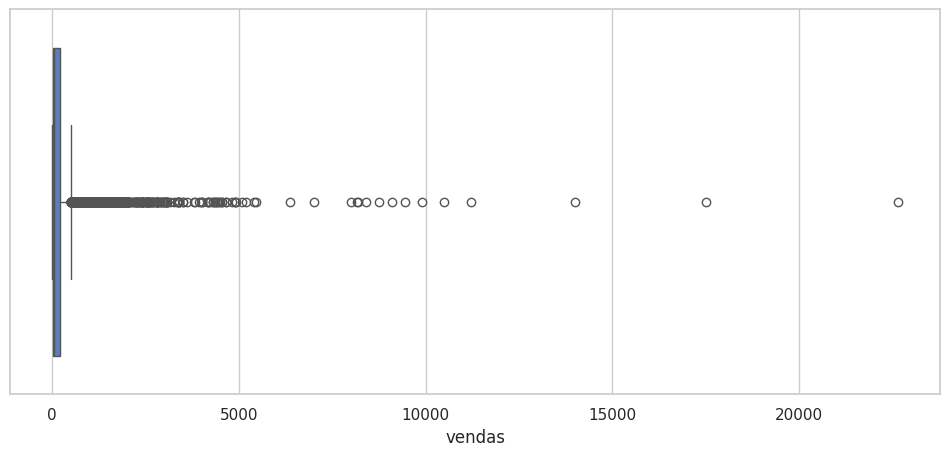

In [27]:
sns.boxplot(x=df['vendas'])

O boxplot de vendas demonstra uma distribuição desbalanceada à direita, com poucos pedidos de valor muito elevado em comparação ao restante dos registros.

<Axes: xlabel='lucro'>

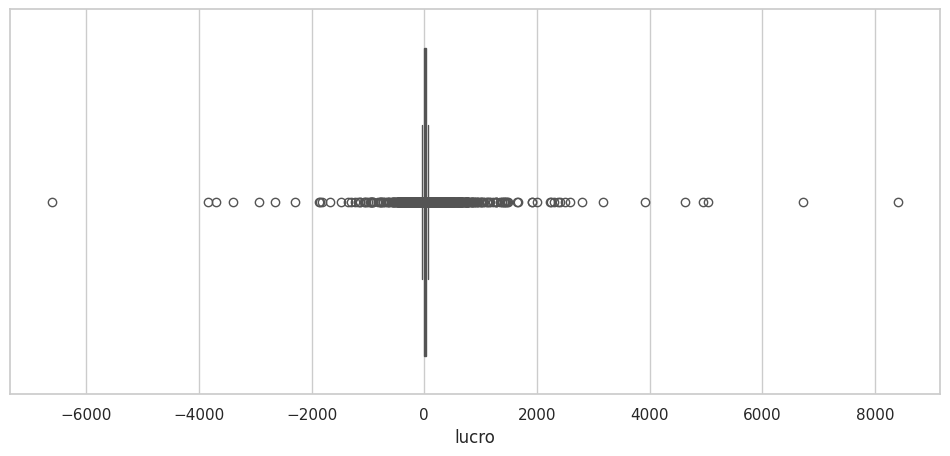

In [28]:
sns.boxplot(x=df['lucro'])

O boxplot de lucro possui muitos outliers positivos, e muitos outliers negativos. Tem-se uma distribuição desbalanceada no geral.

<Axes: xlabel='margem_lucro'>

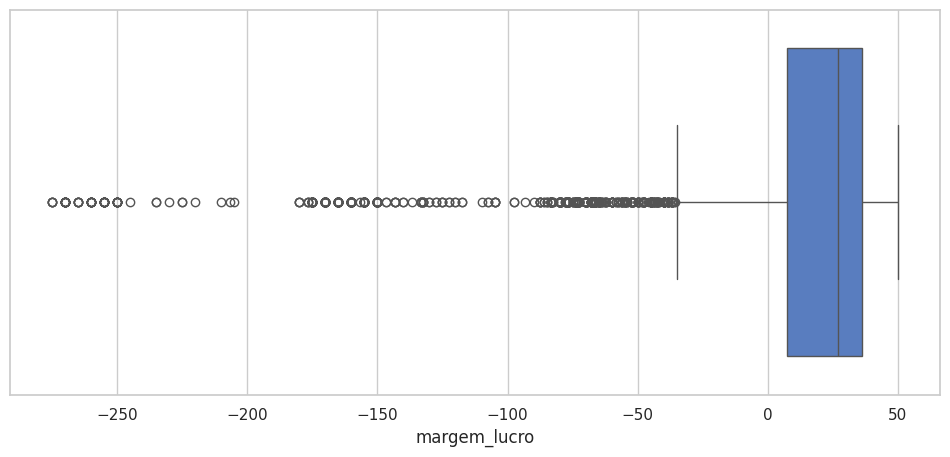

In [29]:
sns.boxplot(x=df['margem_lucro'])

O boxplot de margem_lucro demonstra uma distribuição desbalanceada à esquerda, com muitos pedidos com a margem de lucro negativa, ou seja, com está perdendo na venda ao invés de lucrar.

DECISÃO EM RELAÇÃO AOS OUTLIERS: Irei manter todos os dados, pois essas quantidades elevadas indica dados reais desbalanceados, e não dados com erro de digitação.

# 3. Análise exploratória:

In [30]:
#Análise Univariada — Conhecendo as Variáveis (excluindo os outliers maiores, pra não distorcer tanto a visualização):

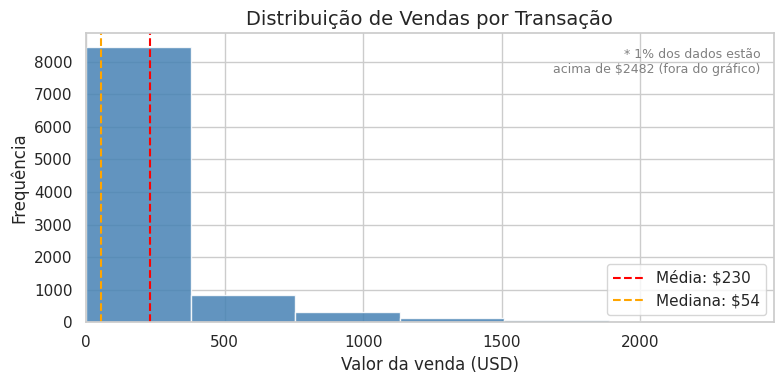


📊 Estatísticas de Vendas:
count     $9,994.00
mean        $229.86
std         $623.25
min           $0.44
25%          $17.28
50%          $54.49
75%         $209.94
max      $22,638.48
Name: vendas, dtype: object


In [31]:
# Distribuição de Vendas
# Usamos o percentil 95 como limite do eixo X para focar onde está a maioria dos dados

p95_vendas = df['vendas'].quantile(0.99)  # valor que cobre 95% dos dados
media_vendas = df['vendas'].mean()
mediana_vendas = df['vendas'].median()

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['vendas'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(media_vendas,   color='red',    linestyle='--', linewidth=1.5, label=f'Média: ${media_vendas:.0f}')
ax.axvline(mediana_vendas, color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: ${mediana_vendas:.0f}')

ax.set_xlim(0, p95_vendas)
ax.set_title('Distribuição de Vendas por Transação', fontsize=14)
ax.set_xlabel('Valor da venda (USD)')
ax.set_ylabel('Frequência')
ax.legend()

pct_outlier = (df['vendas'] > p95_vendas).mean() * 100
ax.text(0.98, 0.95, f'* {pct_outlier:.0f}% dos dados estão\nacima de ${p95_vendas:.0f} (fora do gráfico)',
        transform=ax.transAxes, ha='right', va='top', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

print('\n📊 Estatísticas de Vendas:')
print(df['vendas'].describe().apply(lambda x: f'${x:,.2f}'))

Eliminando a maior parte dos outiers, podemos ver as vendas "reais", ou seja, os casos mais prováveis do dia a dia na empresa. Assim, temos que a média de valor de vendas é de 230 dólares e a mediana de 54 dólares, há uma diferença, mas não tão expressiva quanto no describe (passos anteriores). Mas ainda sim, há vendas com valores mais altos que puxam a média pra cima da mediana. Outra métrica relevante são os valores máximos e mínimos, há vendas com valor abaixo de 1 dólar, e vendas que chegam a valores acima de 22000 dólares. Ou seja, o perfil dos clientes deve variar bastante.

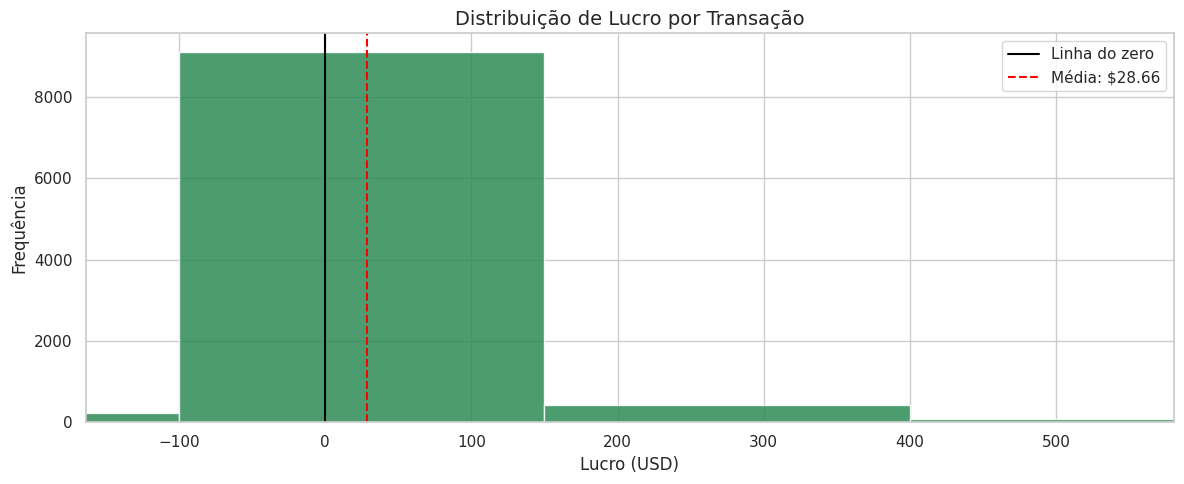


⚠️  18.7% das transações tiveram lucro NEGATIVO (prejuízo)
✅  81.3% das transações tiveram lucro positivo


In [32]:
# Distribuição de Lucro
# Importante: pode haver lucros NEGATIVOS (prejuízo)
# Limitou-se o eixo X entre os percentis 2% e 98% para focar na distribuição central

p02_lucro = df['lucro'].quantile(0.02)
p98_lucro = df['lucro'].quantile(0.99)
media_lucro = df['lucro'].mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df['lucro'], bins=60, color='seagreen', edgecolor='white', alpha=0.85)
ax.axvline(0,           color='black', linestyle='-',  linewidth=1.5, label='Linha do zero')
ax.axvline(media_lucro, color='red',   linestyle='--', linewidth=1.5, label=f'Média: ${media_lucro:.2f}')

ax.set_xlim(p02_lucro, p98_lucro)
ax.set_title('Distribuição de Lucro por Transação', fontsize=14)
ax.set_xlabel('Lucro (USD)')
ax.set_ylabel('Frequência')
ax.legend()

plt.tight_layout()
plt.show()

pct_prejuizo = (df['lucro'] < 0).mean() * 100
print(f'\n⚠️  {pct_prejuizo:.1f}% das transações tiveram lucro NEGATIVO (prejuízo)')
print(f'✅  {100 - pct_prejuizo:.1f}% das transações tiveram lucro positivo')

O valor de lucro ficou bem acima do valor do prejuízo, 81,3% das vendas gerou lucro, e 18,7% geraram prejuízo. Isso indica que a empresa está saudável, no entanto, tem uma boa margem de melhora, para diminuir ainda mais o prejuízo existente.

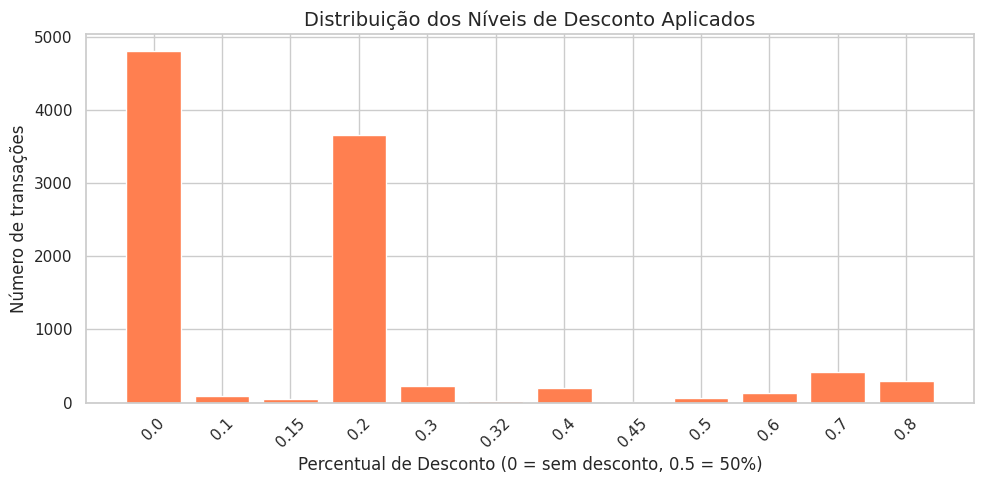


📊 48.0% das transações não receberam desconto
   Desconto médio aplicado: 30.0% (apenas quando há desconto)


In [33]:
# Distribuição de Descontos
# O desconto vai de 0 (sem desconto) a 1 (100% de desconto)
fig, ax = plt.subplots(figsize=(10, 5))

contagem_desconto = df['desconto'].value_counts().sort_index()
ax.bar(contagem_desconto.index.astype(str), contagem_desconto.values, color='coral', edgecolor='white')
ax.set_title('Distribuição dos Níveis de Desconto Aplicados', fontsize=14)
ax.set_xlabel('Percentual de Desconto (0 = sem desconto, 0.5 = 50%)')
ax.set_ylabel('Número de transações')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

sem_desconto = (df['desconto'] == 0).mean() * 100
print(f'\n📊 {sem_desconto:.1f}% das transações não receberam desconto')
print(f'   Desconto médio aplicado: {df[df["desconto"] > 0]["desconto"].mean() * 100:.1f}% (apenas quando há desconto)')

Tem-se que quase metade das vendas não recebe desconto, ou seja, quase metade recebe desconto. Esse é um índice alto, que vale uma investigação maior em relação a estrutura da empresa, que exige mais dados. Minha sugestão seria verificar o porquê desses descontos. Ocorre pelo alto valor dos itens? Para fidelizar os clientes? Algum vendedor específico tem maior tendência a dar descontos? Há queima de estoque ou algum outro evento relacionado a desontos?

Há também a informação do valor médio aplicado, não vezes que se há desconto, que é de 30%, também um valor alto. Como comentei acima, isso me gera curiosidade pra buscar mais dados, e verificar uma melhor adequação em relação aos descontos, pois olhando apenas pra esses dados, tenho a impressão de que os descontos são elevados.

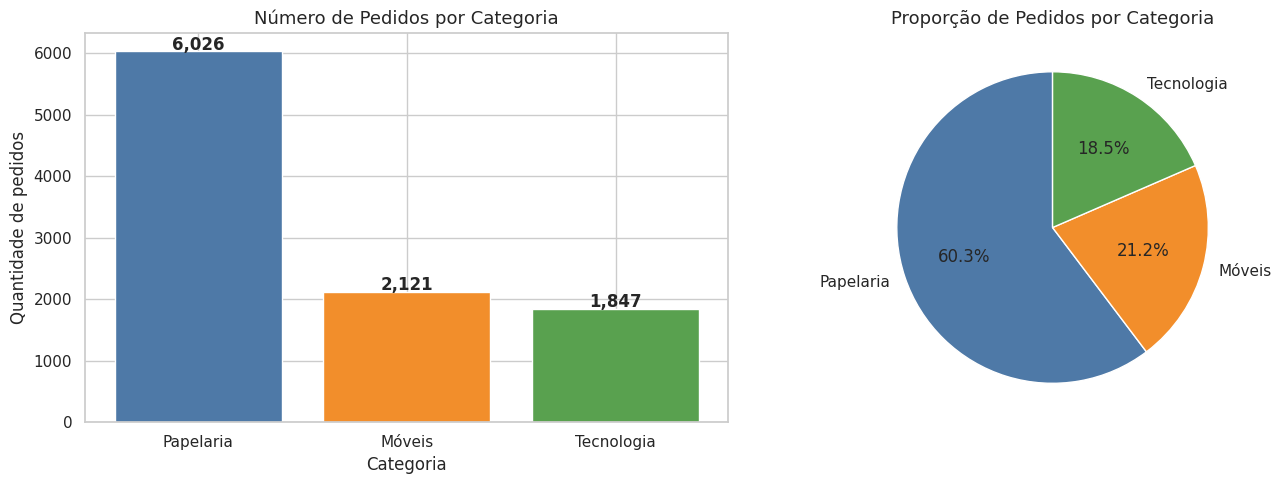

In [34]:
# Distribuição por Categoria de Produto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contagem_cat = df['categoria'].value_counts()

# Gráfico de barras
axes[0].bar(contagem_cat.index, contagem_cat.values, color=['#4e79a7', '#f28e2b', '#59a14f'], edgecolor='white')
axes[0].set_title('Número de Pedidos por Categoria', fontsize=13)
axes[0].set_xlabel('Categoria')
axes[0].set_ylabel('Quantidade de pedidos')
for i, v in enumerate(contagem_cat.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

# Gráfico de pizza
axes[1].pie(contagem_cat.values, labels=contagem_cat.index, autopct='%1.1f%%',
            colors=['#4e79a7', '#f28e2b', '#59a14f'], startangle=90)
axes[1].set_title('Proporção de Pedidos por Categoria', fontsize=13)

plt.tight_layout()
plt.show()

A categoria que mais se destaca, em número de pedidos, desparadamente, é a de papelaria. Nota-se que esse é o principal item da loja, esses dados auxiliam a equipe de marketing, onde as campanhas podem se voltar a promover as categorias segundárias, que possuem maior valor agregado (móveis e itens de tecnologia).

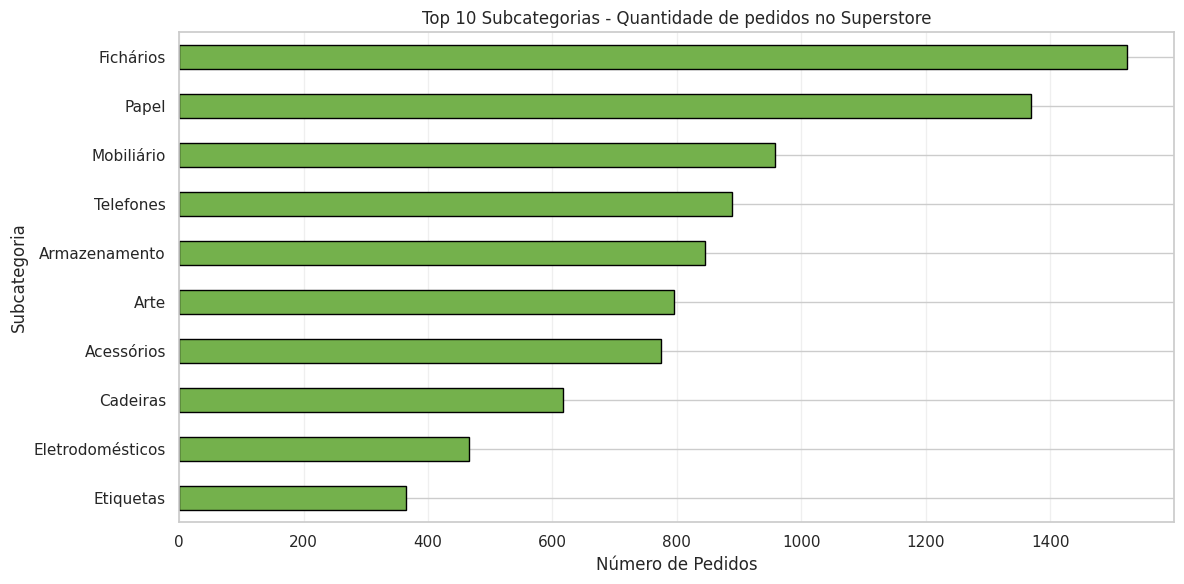

In [35]:
#Top 10 subcategorias por número de pedidos
top_subcat = df['subcategoria'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_subcat.plot(
    kind='barh',
    edgecolor='black',
    color='#74b14c'
)
plt.xlabel('Número de Pedidos')
plt.ylabel('Subcategoria')
plt.title('Top 10 Subcategorias - Quantidade de pedidos no Superstore')
plt.gca().invert_yaxis() #Subcategoria mais popular em cima
plt.grid(axis='x',alpha=0.3)
plt.tight_layout()
plt.show()

As duas primeiras subcategorias com mais pedidos, são relacionadas a papelaria, seguidas por móveis, em terceiro lugar. Essas 3 categorias são as mais expressivas em número de pedidos. Itens de papelaria, no geral, não possuem alto valor agregado, no entanto, a subcategoria móveis possui um bom prospecto, indicando possibilidade de maior investimento relacionados a esses itens (possuem alto valor agregado).

In [36]:
# Distribuição por Segmento de Cliente
contagem_seg = df['segmento'].value_counts()

fig = px.bar(
    x=contagem_seg.index,
    y=contagem_seg.values,
    title='Número de Pedidos por Segmento de Cliente',
    labels={'x': 'Segmento', 'y': 'Número de pedidos'},
    color=contagem_seg.index,
    color_discrete_sequence=px.colors.qualitative.Set2,
    text=contagem_seg.values
)
fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False)
fig.show()

A principal clientela da loja são consumidores comuns, seguidos por empresas, e por último temos pessoas que trabalham de forma remota. Isso é mais um dado relevante para a equipe de marketing poder direcionar melhor suas campanhas de acordo com o perfil que deseja atingir.

In [37]:
#Análise Bivariada — Relacionando as Variáveis

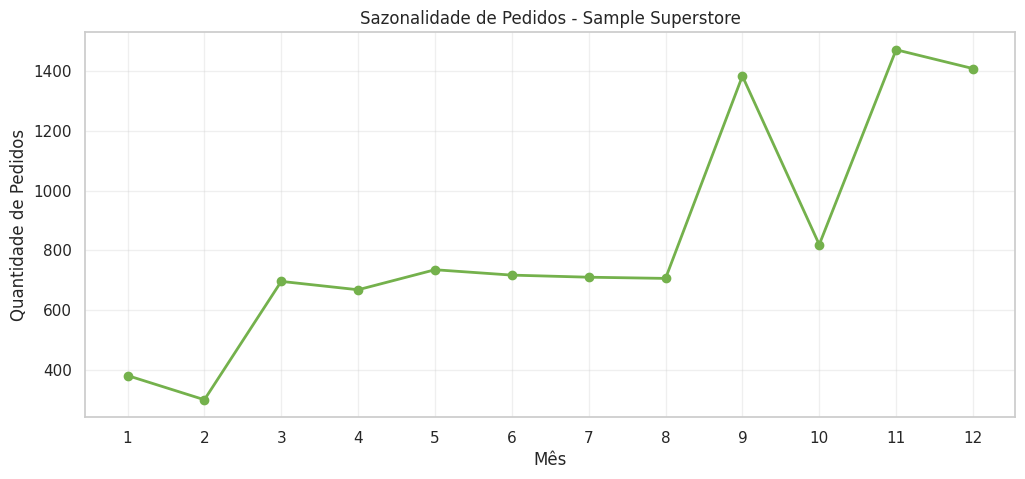

In [38]:
#Visualizando Sazonalidade: Pedidos por Período

#Quantidade de pedidos mês
pedidos_por_mes = (
    df.groupby('mes')
    .size()
    .reset_index(name='contagem'))

plt.figure(figsize=(12,5))
plt.plot(pedidos_por_mes['mes'],
        pedidos_por_mes['contagem'],
        marker='o',linewidth=2,color='#74b14c')
plt.xlabel('Mês')
plt.ylabel('Quantidade de Pedidos')
plt.title('Sazonalidade de Pedidos - Sample Superstore')
plt.xticks(range(1,13))
plt.grid(True,alpha=0.3)
plt.show()

Meses com baixa em pedidos: Janeiro e Fevereiro;
Meses com quantidade de pedidos medianas: de Março até Agosto, e depois de um pico, temos Outubro;
Meses com alta quantidade de pedidos: Setembro, Novembro e Dezembro.

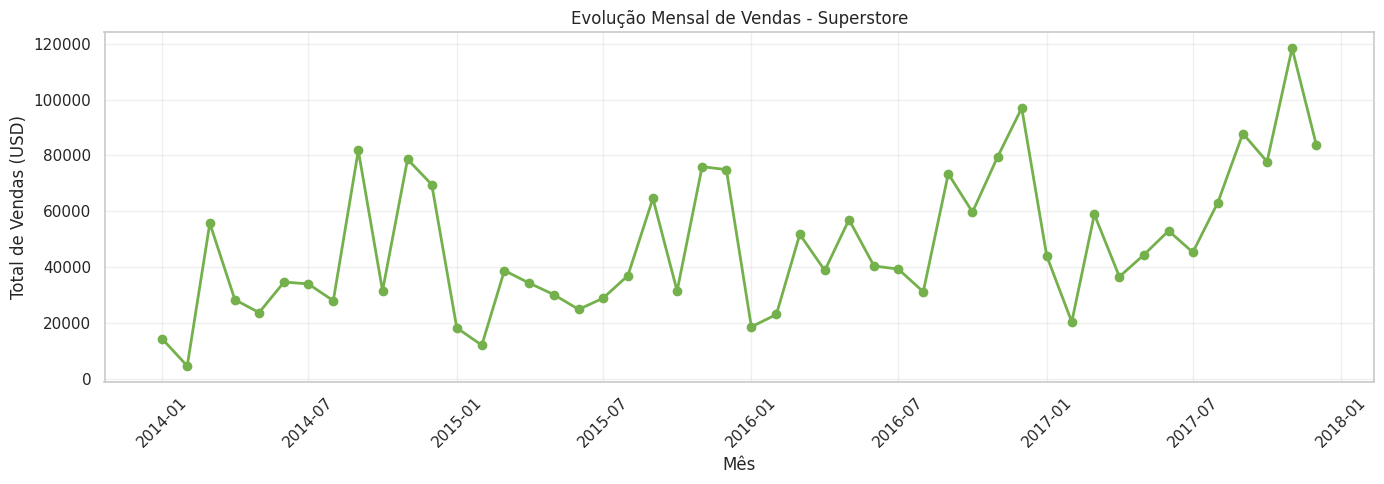

In [39]:
#Vendas por mês (Sazonalidade do Superstore)
vendas_mes = df.groupby(
    df['data_pedido'].dt.to_period('M'))['vendas'].sum()
vendas_mes.index = vendas_mes.index.to_timestamp()

plt.figure(figsize=(14,5))
plt.plot(vendas_mes.index, vendas_mes.values,
        marker='o',linewidth=2,color='#74b14c')
plt.xlabel('Mês')
plt.ylabel('Total de Vendas (USD)')
plt.title('Evolução Mensal de Vendas - Superstore')
plt.xticks(rotation=45)
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

O padrão de vendas mensais se repete no decorrer do histórico anual de 2014 a 2018. No entanto, destacasse que a partir do segundo semestre de 2016, há um aumento considerável no valor total de vendas nos meses de pico.

In [43]:
# Vendas e Lucro por Ano
resumo_anual = df.groupby('ano').agg(
    total_vendas=('vendas', 'sum'),
    total_lucro=('lucro', 'sum'),
    num_pedidos=('id_pedido', 'nunique')
).reset_index()

fig = make_subplots(rows=1, cols=3,
                    subplot_titles=['Vendas por Ano', 'Lucro por Ano', 'Nº de Pedidos por Ano'])

for i, (col, titulo) in enumerate([('total_vendas','Vendas'), ('total_lucro','Lucro'), ('num_pedidos','Pedidos')]):
    fig.add_trace(
        go.Bar(x=resumo_anual['ano'].astype(str), y=resumo_anual[col],
               marker_color='steelblue', name=titulo,
               text=resumo_anual[col].apply(lambda x: f'{x:,.0f}'),
               textposition='outside'),
        row=1, col=i+1
    )

fig.update_layout(title='Crescimento Anual do Negócio', showlegend=False, height=450)
fig.show()

Os gráficos acima complementam as análises anteriores, onde o número de vendas, o lucro e o número de pedidos aumentam proporcionalmente, principalmente de 2016 para 2017.

In [44]:
# Tendência Mensal de Vendas e Lucro (agrupado por mês do ano, ignorando o ano)
# Isso nos mostra a sazonalidade — quais meses performam melhor

meses_ordem = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

resumo_mensal = df.groupby(['mes', 'nome_mes']).agg(
    total_vendas=('vendas', 'sum'),
    total_lucro=('lucro', 'sum')
).reset_index().sort_values('mes')

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=['Vendas Mensais (acumulado 2016-2017)',
                                    'Lucro Mensal (acumulado 2016-2017)'])

fig.add_trace(
    go.Scatter(x=resumo_mensal['nome_mes'], y=resumo_mensal['total_vendas'],
               mode='lines+markers', fill='tozeroy',
               line=dict(color='steelblue', width=2.5), name='Vendas'),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=resumo_mensal['nome_mes'], y=resumo_mensal['total_lucro'],
               mode='lines+markers', fill='tozeroy',
               line=dict(color='seagreen', width=2.5), name='Lucro'),
    row=2, col=1
)

fig.update_layout(title='Sazonalidade — Desempenho por Mês (2016–2017)', height=550, showlegend=False)
fig.show()

print('\n📌 Insight: O quarto trimestre (Out-Nov-Dez) concentra os maiores volumes de vendas — padrão típico de varejo.')


📌 Insight: O quarto trimestre (Out-Nov-Dez) concentra os maiores volumes de vendas — padrão típico de varejo.


Novamente vemos o apontamento de que os melhores meses, em relação a quantidade de vendas, e consequentemente do lucro, são: Setembro, Outubro, Novembro e Dezembro (especificamente para 2016 e 2017).

In [42]:
# Top Subcategorias por Lucro (do maior lucro ao maior prejuízo)
# Este gráfico revela quais produtos são problemáticos
lucro_subcat = df.groupby('subcategoria')['lucro'].sum().sort_values(ascending=True).reset_index()

# Define cor vermelha para prejuízo e verde para lucro positivo
lucro_subcat['cor'] = lucro_subcat['lucro'].apply(lambda x: '#d62728' if x < 0 else '#2ca02c')

fig = go.Figure(go.Bar(
    x=lucro_subcat['lucro'],
    y=lucro_subcat['subcategoria'],
    orientation='h',
    marker_color=lucro_subcat['cor'],
    text=lucro_subcat['lucro'].apply(lambda x: f'${x:,.0f}'),
    textposition='outside'
))

fig.add_vline(x=0, line_width=1.5, line_color='black')
fig.update_layout(
    title='Lucro Total por Subcategoria (vermelho = prejuízo)',
    xaxis_title='Lucro Total (USD)',
    yaxis_title='',
    height=600
)
fig.show()

print('\n📌 Insight: Mesas e Estantes (Móveis) geram prejuízo! Provavelmente por excesso de descontos.')


📌 Insight: Mesas e Estantes (Móveis) geram prejuízo! Provavelmente por excesso de descontos.


Esta análise específica de subitens de venda que estão gerando prejuízo já direciona melhor a tomada de decisão, ou comentei, até um novo levantamento de dados em torno desses itens (Suprimentos, Estantes e Mesas), pra verificar o problema com maior contexto.

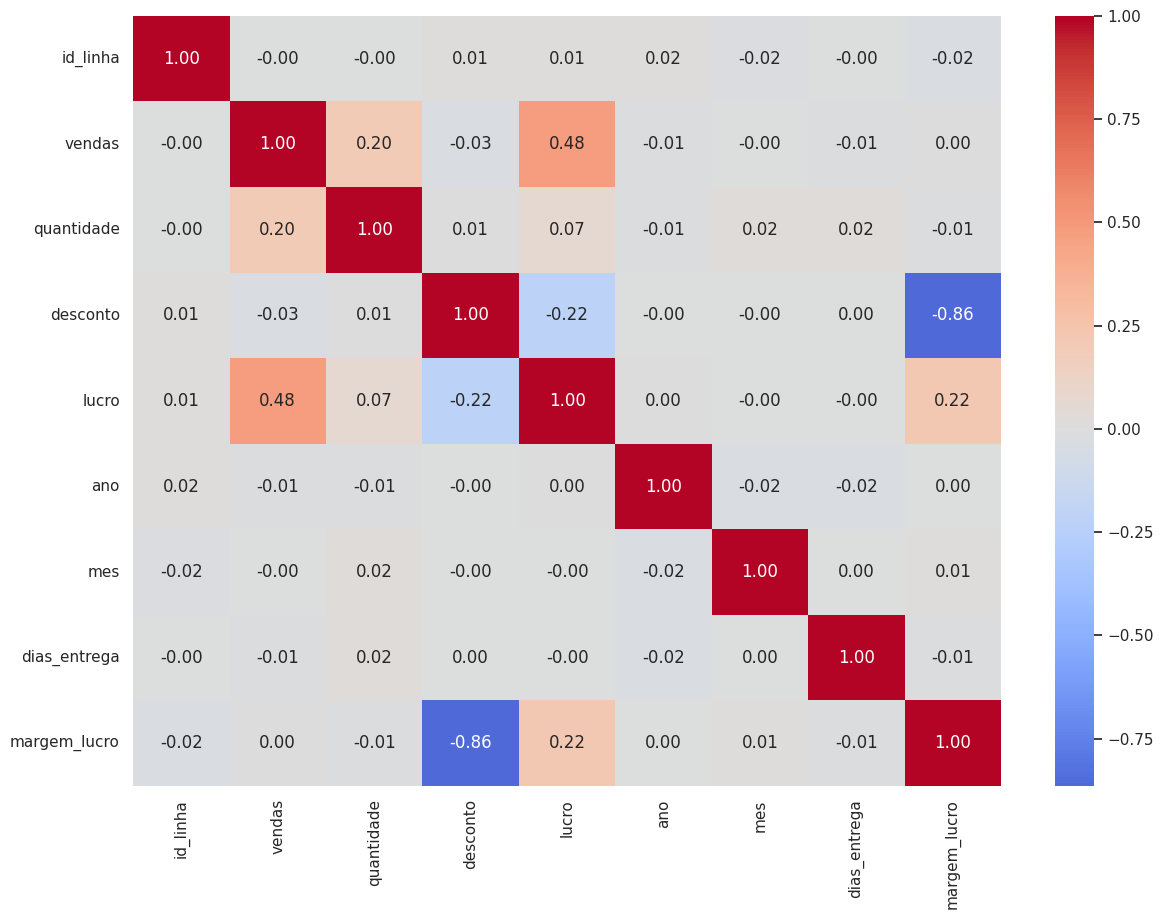

In [40]:
#Matriz de correlação
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.show()

A matriz de correlação condiz com o df, onde, Discount - Profit, e Discount - margem_lucro, possuem alta correlação negativa, e Profit e Vendas possuem correlação média. Ou seja, quanto maior o desconto, menor o lucro, e vice-versa. E, há média relação com o tamanho do lucro em relação ao tamanho do valor da venda.

Essa matriz também já da um indicativo onde as variáveis: Profit, Sales e Discount e margem_lucro são as mais relevantes.

<Axes: xlabel='lucro', ylabel='vendas'>

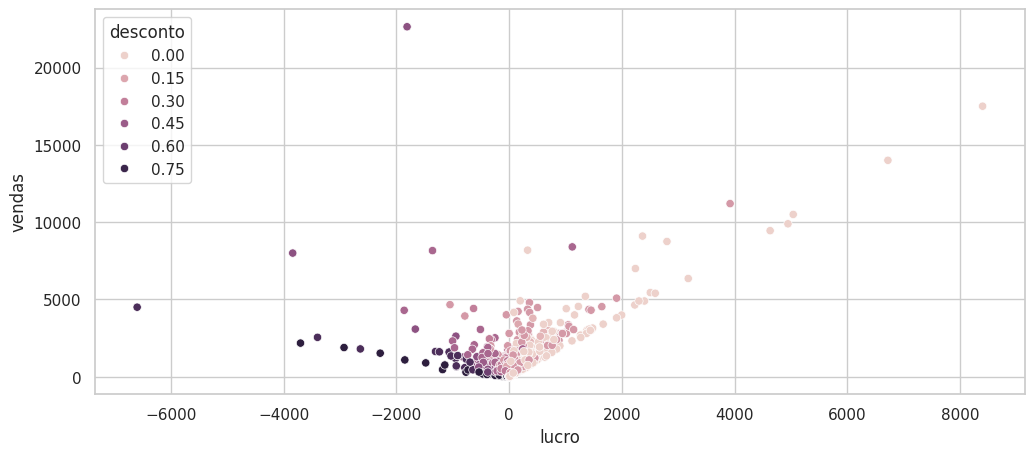

In [41]:
#Análise de Dispersão dos dados
sns.scatterplot(
    data=df,
    x='lucro',
    y='vendas',
    hue='desconto'
)

Temos que as vendas com valores mais altos, possuem disconto mais baixo e/ou zero, o que gera lucro. Já, por outro lado, vemos que a maior parte dos descontos acima de 30% geram prejuízo. Uma observação importante é que todas as vendas com desconto altíssimo, acima de 75%, são vendas com valor abaixo de $5.000.

# 4. Construção de dashboard

Último passo: **levar esses dados para o dashboard**. O Looker Studio não acessa o Python diretamente — ele precisa de um arquivo CSV com os dados já tratados.

Vamos exportar uma versão enxuta do dataset, contendo apenas as colunas que realmente vamos usar no dashboard. Isso é importante por dois motivos:
1. **Desempenho** — arquivo menor carrega mais rápido no Looker Studio
2. **Clareza** — o analista que montar o dashboard não vai se perder em colunas desnecessárias

> 💡 Esse arquivo CSV é a **ponte entre o Python e o Looker Studio**. Tudo que você quiser visualizar no dashboard precisa estar aqui.

In [45]:
# Cria a coluna de classificação de outlier antes de exportar
Q1 = df['vendas'].quantile(0.25)
Q3 = df['vendas'].quantile(0.75)
IQR = Q3 - Q1
limite_sup = Q3 + 1.5 * IQR

df['porte_pedido'] = df['vendas'].gt(limite_sup).map({
    False: 'Pedido Normal',
    True : 'Pedido Alto Valor'
})

# Seleciona as colunas para o dashboard
colunas_dashboard = [
    'id_pedido', 'data_pedido', 'ano', 'mes', 'nome_mes',
    'segmento', 'regiao', 'estado', 'cidade',
    'categoria', 'subcategoria', 'nome_produto',
    'modo_envio', 'dias_entrega',
    'vendas', 'quantidade', 'desconto', 'lucro', 'margem_lucro',
    'porte_pedido'
]

df_dashboard = df[colunas_dashboard].copy()

# Salva o arquivo CSV
df_dashboard.to_csv('superstore_dashboard.csv', index=False)

print(f'✅ Arquivo exportado: superstore_dashboard.csv')
print(f'   Dimensões: {df_dashboard.shape[0]:,} linhas × {df_dashboard.shape[1]} colunas')
print()
print('Colunas incluídas no dashboard:')
for col in colunas_dashboard:
    print(f'   • {col}')

✅ Arquivo exportado: superstore_dashboard.csv
   Dimensões: 9,994 linhas × 20 colunas

Colunas incluídas no dashboard:
   • id_pedido
   • data_pedido
   • ano
   • mes
   • nome_mes
   • segmento
   • regiao
   • estado
   • cidade
   • categoria
   • subcategoria
   • nome_produto
   • modo_envio
   • dias_entrega
   • vendas
   • quantidade
   • desconto
   • lucro
   • margem_lucro
   • porte_pedido
